In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [ ]:
import os

# List the contents of the downloaded dataset path
print(f"Contents of {path}:")
for item in os.listdir(path):
    print(f"- {item}")

Contents of /kaggle/input/plantvillage-dataset:
- plantvillage dataset


In [ ]:
import os

dataset_root = os.path.join(path, 'plantvillage dataset')

print(f"Contents of {dataset_root}:")
for item in os.listdir(dataset_root):
    print(f"- {item}")

Contents of /kaggle/input/plantvillage-dataset/plantvillage dataset:
- segmented
- grayscale
- color


In [ ]:
import os

color_data_path = os.path.join(dataset_root, 'color')

print(f"Contents of {color_data_path}:")
for item in os.listdir(color_data_path):
    print(f"- {item}")

Contents of /kaggle/input/plantvillage-dataset/plantvillage dataset/color:
- Tomato___Late_blight
- Tomato___healthy
- Grape___healthy
- Orange___Haunglongbing_(Citrus_greening)
- Soybean___healthy
- Squash___Powdery_mildew
- Potato___healthy
- Corn_(maize)___Northern_Leaf_Blight
- Tomato___Early_blight
- Tomato___Septoria_leaf_spot
- Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
- Strawberry___Leaf_scorch
- Peach___healthy
- Apple___Apple_scab
- Tomato___Tomato_Yellow_Leaf_Curl_Virus
- Tomato___Bacterial_spot
- Apple___Black_rot
- Blueberry___healthy
- Cherry_(including_sour)___Powdery_mildew
- Peach___Bacterial_spot
- Apple___Cedar_apple_rust
- Tomato___Target_Spot
- Pepper,_bell___healthy
- Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
- Potato___Late_blight
- Tomato___Tomato_mosaic_virus
- Strawberry___healthy
- Apple___healthy
- Grape___Black_rot
- Potato___Early_blight
- Cherry_(including_sour)___healthy
- Corn_(maize)___Common_rust_
- Grape___Esca_(Black_Measles)
- Raspberry__

In [ ]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

# Define transformations for the images
# Common transforms include resizing, converting to tensor, and normalization.
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to a common size
    transforms.ToTensor(),         # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet stats
])

# Load the dataset using ImageFolder
# This assumes your directory structure is `root/class_name/image.jpg`
full_dataset = torchvision.datasets.ImageFolder(root=color_data_path, transform=transform)

# Determine the number of classes
num_classes = len(full_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Class names: {full_dataset.classes}")

Number of classes: 38
Class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotte

In [ ]:
# Create a DataLoader for the dataset
# This will provide batches of images and labels during training
batch_size = 32
train_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)

print(f"Number of batches in DataLoader: {len(train_loader)}")

# You can iterate through the DataLoader to get batches:
# for images, labels in train_loader:
#    print(images.shape, labels.shape)
#    break

Number of batches in DataLoader: 1698


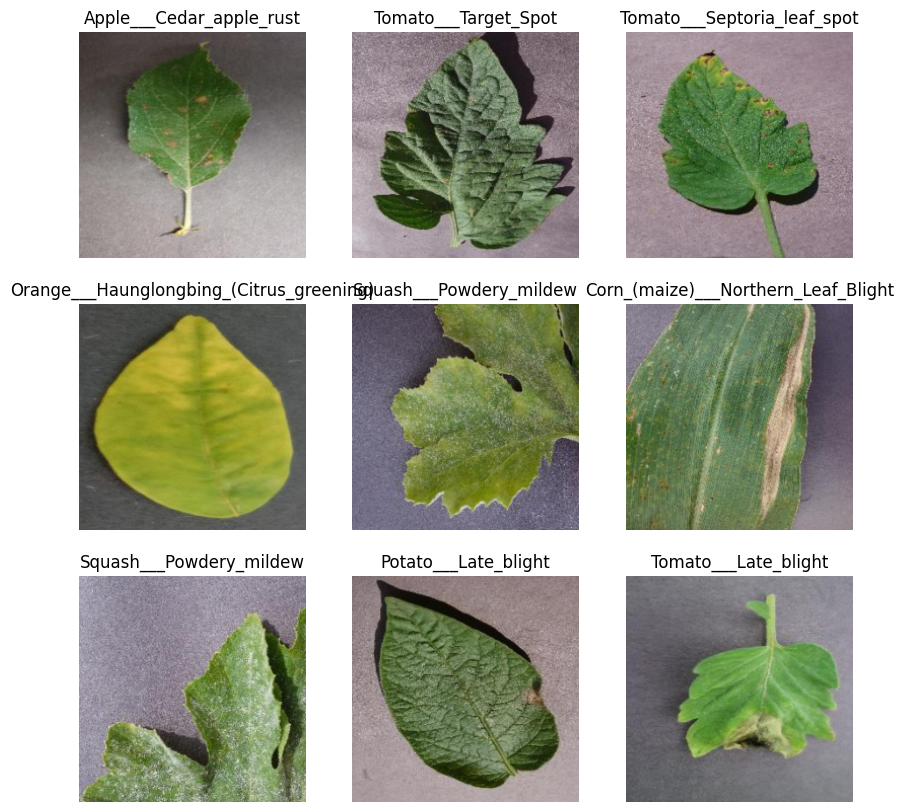

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Unnormalize function (reverse of the normalization transform)
def unnormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img * std[:, None, None] + mean[:, None, None] # Apply to C, H, W format
    img = np.clip(img, 0, 1)
    return img

plt.figure(figsize=(10, 10))
for i, (images, labels) in enumerate(train_loader):
    if i >= 1: # Take one batch
        break

    for j in range(min(len(images), 9)): # Display first 9 images from the batch
        ax = plt.subplot(3, 3, j + 1)

        # Convert image tensor to numpy array for display and unnormalize
        img_np = images[j].numpy()
        img_np = unnormalize(img_np) # C, H, W format, then unnormalize
        img_np = np.transpose(img_np, (1, 2, 0)) # Change to H, W, C for imshow

        plt.imshow(img_np)
        plt.title(full_dataset.classes[labels[j]])
        plt.axis("off")
plt.show()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

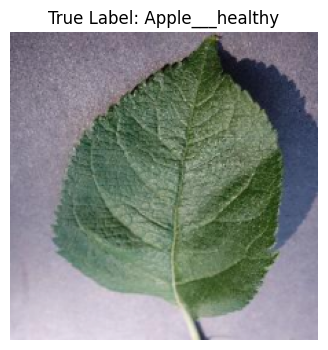


Predictions:
Label: Potato___Healthy, Confidence: 0.9831
Label: Potato___Late_Blight, Confidence: 0.0091
Label: Invalid, Confidence: 0.0033
Label: Corn___Common_Rust, Confidence: 0.0010
Label: Potato___Early_Blight, Confidence: 0.0009


In [ ]:
from transformers import pipeline
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Unnormalize function (copied from previous cell for self-containment)
def unnormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    # Ensure img has 3 dimensions (C, H, W) before unnormalizing
    if img.ndim == 3:
        img = img * std[:, None, None] + mean[:, None, None]
    else:
        # Handle cases where image might be single channel or different format if needed
        pass # Or raise an error
    img = np.clip(img, 0, 1)
    return img

# Load the pre-trained vision transformer model
classifier = pipeline("image-classification", model="wambugu71/crop_leaf_diseases_vit")

# Get one image from the train_loader
for images, labels in train_loader: # train_loader is already defined
    sample_image_tensor = images[0] # Take the first image from the batch
    sample_label_idx = labels[0].item() # Get its label index
    sample_class_name = full_dataset.classes[sample_label_idx] # Get its class name
    break

# Unnormalize the image tensor and convert to numpy array (H, W, C)
unnormalized_img_np = unnormalize(sample_image_tensor.numpy())
unnormalized_img_np = np.transpose(unnormalized_img_np, (1, 2, 0)) # C, H, W to H, W, C

# Convert to PIL Image
# Scale to 0-255 and convert to uint8 before creating PIL Image
pil_image = Image.fromarray((unnormalized_img_np * 255).astype(np.uint8))

# Display the image and its true label
plt.figure(figsize=(4, 4))
plt.imshow(pil_image)
plt.title(f"True Label: {sample_class_name}")
plt.axis("off")
plt.show()

# Run classification on this image
predictions = classifier(pil_image)

print("\nPredictions:")
for pred in predictions:
    print(f"Label: {pred['label']}, Confidence: {pred['score']:.4f}")

In [ ]:
import os
import torch
import torchvision
from torchvision import transforms, models
from torch.utils.data import DataLoader, random_split

# 1. Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Set path to the color images folder
color_data_path = os.path.join(path, 'plantvillage dataset', 'color')

# 3. Data Transformations with Augmentation for Training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. Load full dataset
full_dataset = torchvision.datasets.ImageFolder(root=color_data_path)
num_classes = len(full_dataset.classes)
class_names = full_dataset.classes

print(f"Total images: {len(full_dataset)} across {num_classes} classes.")

# 5. Split into Train (80%) and Validation (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

# Apply transforms specifically to each split
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

# 6. DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

Using device: cuda
Total images: 54305 across 38 classes.


In [ ]:
import torch.nn as nn
from torchvision.models import vit_b_16, ViT_B_16_Weights

# Load pre-trained Vision Transformer
weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights)

# Replace the final linear classification layer (heads.head)
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, num_classes)

# Move model to GPU/CPU
model = model.to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 58.0MB/s]


In [ ]:
import torch.optim as optim

# Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# Cosine Annealing Learning Rate Scheduler
epochs = 3
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [ ]:
from tqdm.auto import tqdm

best_val_acc = 0.0

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # Step the learning rate scheduler
    scheduler.step()

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = val_loss / total_val
    val_acc = correct_val / total_val

    print(f"\n--- Epoch {epoch+1}/{epochs} Summary ---")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
    print(f"Current LR: {scheduler.get_last_lr()[0]:.6f}\n")

    # Save Best Model Weights
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_plant_disease_vit.pth")
        print(f"Checkpoint saved with Validation Accuracy: {val_acc*100:.2f}%\n")

Epoch 1/3 [Train]:   0%|          | 0/1358 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ae54f54ee80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ae54f54ee80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 1/3 [Val]:   0%|          | 0/340 [00:00<?, ?it/s]


--- Epoch 1/3 Summary ---
Train Loss: 0.0566 | Train Acc: 98.22%
Val Loss:   0.0461 | Val Acc:   98.51%
Current LR: 0.000075

Checkpoint saved with Validation Accuracy: 98.51%



Epoch 2/3 [Train]:   0%|          | 0/1358 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ae54f54ee80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ae54f54ee80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


--- Epoch 2/3 Summary ---
Train Loss: 0.0185 | Train Acc: 99.41%
Val Loss:   0.0297 | Val Acc:   99.06%
Current LR: 0.000025

Checkpoint saved with Validation Accuracy: 99.06%



Epoch 3/3 [Train]:   0%|          | 0/1358 [00:00<?, ?it/s]

Epoch 3/3 [Val]:   0%|          | 0/340 [00:00<?, ?it/s]


--- Epoch 3/3 Summary ---
Train Loss: 0.0033 | Train Acc: 99.92%
Val Loss:   0.0113 | Val Acc:   99.62%
Current LR: 0.000000

Checkpoint saved with Validation Accuracy: 99.62%



In [ ]:
import os
from google.colab import files

# The best model weights were already saved during training in 'best_plant_disease_vit.pth'
# We will just download that file.

# Check if the file exists before zipping
model_path = "best_plant_disease_vit.pth"
if os.path.exists(model_path):
    # Zip the saved model file
    !zip -r plant_disease_model_weights.zip {model_path}
    # Download the zipped file
    files.download("plant_disease_model_weights.zip")
else:
    print(f"Error: Model weights file '{model_path}' not found.")

  adding: best_plant_disease_vit.pth (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json
import os
import shutil
import torch
from google.colab import files

# 1. Create export directory
export_dir = "./plant_disease_deployment_package"
os.makedirs(export_dir, exist_ok=True)

# 2. Package PyTorch weights (.pth)
pth_filename = "best_plant_disease_vit.pth"
if os.path.exists(pth_filename):
    shutil.copy(pth_filename, os.path.join(export_dir, pth_filename))
    print(f"Copied existing {pth_filename}")
else:
    # Save directly from memory if file isn't in root
    torch.save(model.state_dict(), os.path.join(export_dir, pth_filename))
    print(f"Saved PyTorch weights to {pth_filename}")

# 3. Export class labels and mappings
class_mapping = {
    "classes": full_dataset.classes,
    "id2label": {i: name for i, name in enumerate(full_dataset.classes)},
    "label2id": {name: i for i, name in enumerate(full_dataset.classes)}
}

with open(os.path.join(export_dir, "classes.json"), "w") as f:
    json.dump(class_mapping, f, indent=4)
print("Saved classes.json")

# 4. Generate local predict.py script
predict_script = '''import json
import os
import sys
import torch
from PIL import Image
from torchvision import transforms
from transformers import AutoModelForImageClassification

BASE_DIR = os.path.dirname(os.path.abspath(__file__))

def load_model():
    classes_path = os.path.join(BASE_DIR, "classes.json")
    with open(classes_path, "r") as f:
        classes_info = json.load(f)

    id2label = {int(k): v for k, v in classes_info["id2label"].items()}
    label2id = classes_info["label2id"]
    num_classes = len(classes_info["classes"])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = AutoModelForImageClassification.from_pretrained(
        "wambugu71/crop_leaf_diseases_vit",
        num_labels=num_classes,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    weights_path = os.path.join(BASE_DIR, "best_plant_disease_vit.pth")
    if os.path.exists(weights_path):
        model.load_state_dict(torch.load(weights_path, map_location=device))

    model.to(device)
    model.eval()
    return model, id2label, device

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict(image_path):
    model, id2label, device = load_model()

    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)[0]
        top_prob, top_idx = torch.topk(probs, 1)

    class_name = id2label[top_idx.item()]
    confidence = top_prob.item() * 100
    return class_name, confidence

if __name__ == "__main__":
    if len(sys.argv) < 2:
        print("Usage: python predict.py <path_to_leaf_image>")
    else:
        test_img = sys.argv[1]
        label, conf = predict(test_img)
        print(f"--- Prediction Result ---")
        print(f"Disease / Status: {label}")
        print(f"Confidence:       {conf:.2f}%")
'''

with open(os.path.join(export_dir, "predict.py"), "w") as f:
    f.write(predict_script)
print("Saved predict.py")

# 5. Generate requirements.txt
requirements = """torch
torchvision
transformers
pillow
"""
with open(os.path.join(export_dir, "requirements.txt"), "w") as f:
    f.write(requirements)
print("Saved requirements.txt")

# 6. Compress and download
shutil.make_archive("plant_disease_deployment_package", 'zip', export_dir)
print("\nDeployment zip created successfully! Downloading to your computer...")
files.download("plant_disease_deployment_package.zip")

Copied existing best_plant_disease_vit.pth
Saved classes.json
Saved predict.py
Saved requirements.txt

Deployment zip created successfully! Downloading to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>